In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [54]:
df = pd.read_csv("/Users/saranraj/PycharmProjects/house_price_prediction/data/featured_house_data.csv")

In [55]:
print(df.shape)

df.head()

(2930, 91)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,SalePrice,TotalSF,TotalBath,HouseAge,RemodAge,IsRemodeled,TotalPorchSF,HasGarage,HasBasement,HasFireplace
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,215000,2736.0,2.0,50,50,0,62,1,1,1
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,105000,1778.0,1.0,49,49,0,120,1,1,0
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,172000,2658.0,1.5,52,52,0,36,1,1,0
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,244000,4220.0,3.5,42,42,0,0,1,1,1
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,189900,2557.0,2.5,13,12,1,34,1,1,1


In [56]:
X = df.drop("SalePrice", axis=1)#x -> predict ->

y = df["SalePrice"]

In [57]:
print(X.shape)
print(y.shape)

(2930, 90)
(2930,)


It Prevents "Cheating" During TrainingA machine learning model learns by looking at the clues (X) and trying to guess the answer (y).If SalePrice is still inside X, the model won't bother learning how Bedrooms or SquareFeet affect the price.It will simply find the SalePrice column inside X, copy it exactly, and get a perfect 100% score during training.


In [58]:
numeric_features=X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include="object"
).columns

In [59]:
print("Numeric Features:", len(numeric_features))

print("Categorical Features:", len(categorical_features))

Numeric Features: 47
Categorical Features: 43


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (2344, 90)
Testing Features : (586, 90)
Training Target  : (2344,)
Testing Target   : (586,)


In [62]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [63]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [67]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [68]:
y_pred = linear_model.predict(X_test)

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Metric	Meaning
MAE	Average prediction error in dollars
RMSE	Penalizes larger prediction errors
R² Score	How well the model explains the variation in house prices


In [70]:
#evaluating the model

mae = mean_absolute_error(y_test, y_pred)

rmse = (mean_squared_error(y_test, y_pred)) ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 15967.83
RMSE: 29368.72
R²  : 0.8924


My baseline Linear Regression model achieved an R² score of approximately 0.8
indicating that it explained nearly 89% of the variance in house prices


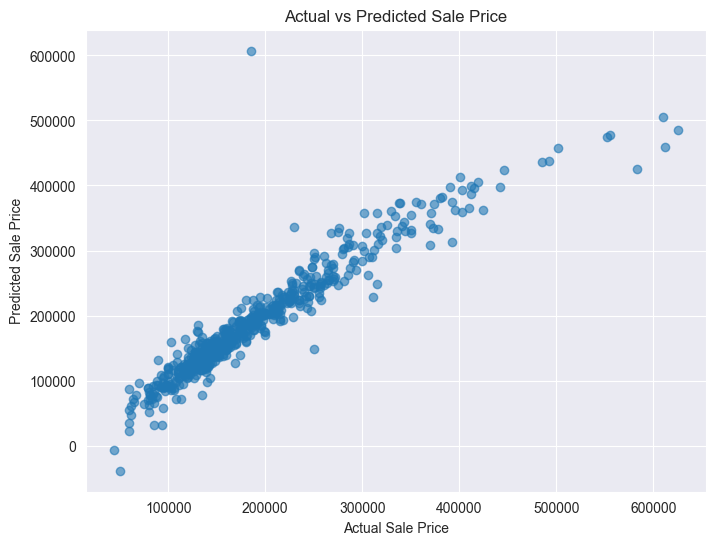

In [71]:
#my model also achieved an MAE of around 16,000 and an RMSE of about 29,000, providing a strong benchmark for evaluating more advanced models.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

In [72]:
residuals = y_test - y_pred

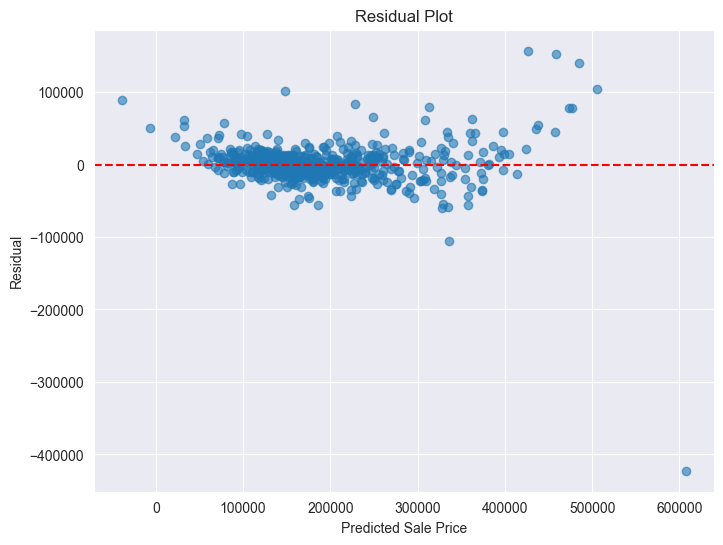

In [73]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()
#a Residual Plot, which is one of the most important diagnostic tools in regression analysis. You use it to check whether a linear regression model is the correct choice for your dataset, or if your model is breaking fundamental statistical assumptions

In [74]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [75]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(random_state=42),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [76]:
results = []

mae (Mean Absolute Error): Tells you the average absolute distance your predictions are from the actual values (measured in the same units as your target variable).rmse (Root Mean Squared Error): Similar to MAE, but it squares the errors before averaging them, meaning it penalizes larger mistakes much more severely.r2 (R² Score): Measures how well your model explains the variance of the data compared to a baseline average line (closer to 1.0 is better).

#Raw Data ➔ [ Preprocessor Step ] ➔ [ Trained Model Step ] ➔ Output Metrics

In [77]:
for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [78]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,14711.845020,23308.418491,0.932238
1,Random Forest,15595.697082,24986.966862,0.922127
2,Ridge Regression,16248.070083,28806.971717,0.896497
3,Linear Regression,15967.825312,29368.720009,0.892421
4,Decision Tree,25039.583618,42136.005483,0.778555


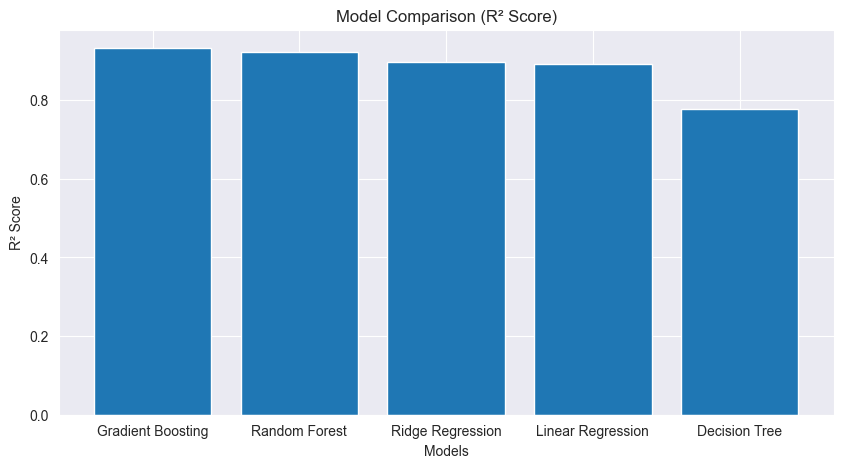

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=0)

plt.show()

In [82]:
best_model = results_df.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model       Gradient Boosting
MAE               14711.84502
RMSE             23308.418491
R2 Score             0.932238
Name: 0, dtype: object


In [91]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting


In [ ]:
#We only tune the best-performing model.
#If Random Forest is best, we tune Random Forest.
#If Gradient Boosting is best, we tune Gradient Boosting.
#This saves time and follows industry practice.

In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:
rf_pipeline = Pipeline(
    steps=[
         ("preprocessor", preprocessor),
         ("model", RandomForestRegressor(random_state=42))
    ]
)


Train multiple models

        ↓
Choose the best one

        ↓
Tune only that model

Visualizing Your Specific ParametersIf you could look inside the grid search process, here is exactly what your three specific parameters look like visually:1. model__n_estimators: [100, 200]The grid search literally builds two different sizes of forests. One configuration builds 100 independent decision trees (like the ones lined up horizontally in the diagram), while the second configuration scales up to 200 independent trees to see if a larger committee yields a more stable, accurate voting majority.2. model__max_depth: [10, 20, None]This controls the vertical height or depth of each tree down from the root node:Setting 10: Limits the tree to a maximum of 10 branching steps from top to bottom.Setting 20: Allows a taller, more detailed tree structure with up to 20 branching steps.Setting None: The tree keeps splitting vertically until every leaf node is completely pure, which can make the diagram exceptionally deep and complex.3. model__min_samples_split: [2, 5]This acts as a gatekeeper at each junction point (node) in the diagram:Setting 2: If a node contains just 2 data points, the tree is allowed to split them one last time into individual leaves.Setting 5: If a node drops down to 4 data points, the tree is forced to stop splitting right there, turning that node into a final leaf even if it isn't completely pure yet.

cv=5

Performs 5-fold cross-validation.

Instead of one train-test split, the model trains and validates five times using different splits, providing a more reliable estimate of performance.

scoring="r2"

We're optimizing for the R² score because it's our primary evaluation metric for regression.

n_jobs=-1

Uses all available CPU cores to speed up the search.


Splitting the DataThe algorithm takes your entire training dataset and shuffles it. It then divides the data into 5 equal-sized chunks called "Folds" (Fold 1, Fold 2, Fold 3, Fold 4, Fold 5).2. The 5-Iteration LoopThe system runs a loop exactly 5 times. In each iteration, it holds out one specific fold as the test set and uses the remaining 4 folds to train the model:Iteration 1: Trains on Folds 2, 3, 4, 5 → Tests on Fold 1 → Saves Score 1Iteration 2: Trains on Folds 1, 3, 4, 5 → Tests on Fold 2 → Saves Score 2Iteration 3: Trains on Folds 1, 2, 4, 5 → Tests on Fold 3 → Saves Score 3Iteration 4: Trains on Folds 1, 2, 3, 5 → Tests on Fold 4 → Saves Score 4Iteration 5: Trains on Folds 1, 2, 3, 4 → Tests on Fold 5 → Saves Score 53. Averaging the ResultsThe system takes the 5 individual scores (in your case, the R² regression scores) and calculates their mathematical average (mean). This final average score is what GridSearchCV uses to judge how good that specific parameter combination actually is.

The n_jobs parameter controls how many processing cores (the "brains" of your computer's CPU) are used to run your grid search at the same time.Here is exactly how -1 works, and what happens if you change it to other numbers:What n_jobs=-1 Actually MeansSetting n_jobs=-1 tells your computer: "Use 100% of my CPU cores."If your computer has 8 CPU cores, Python will launch 8 separate processes simultaneously. Instead of training your 60 cross-validation models one after the other in a long, slow line, it trains 8 models at the exact same millisecond. As soon as one core finishes a model, it instantly grabs the next one until all 60 are done.The Benefit: It makes your code run at maximum speed.The Downside: Your computer might lag, freeze, or become slow to respond if you try to browse the internet or watch a video while the code is running, because the CPU has no power left over for anything else.What Happens If You Change the Value?You can pass different integers into n_jobs to control your computer's workload:ValueWhat It Does to Your CPUBest Used For...n_jobs=1 (Default)Uses exactly one CPU core. The rest of your computer stays perfectly fast, but your machine learning grid search will run very slowly.Tiny datasets, or when you are running code in the background and need your computer to stay smooth.n_jobs=2 or 3Uses exactly that specific number of cores.Explicitly limiting resources on shared servers or older laptops.n_jobs=-2Uses all cores except for one. (Total Cores - 1). If you have 8 cores, it will use 7.The Sweet Spot. It trains your model at nearly maximum speed while leaving one core completely free so you can still use your mouse, watch videos, or use Discord without lagging

In [95]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

In [96]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [97]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [90]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


After your computer finishes running all those parallel cross-validation loops, it keeps the results hidden inside the memory of the grid_search object. Running these two lines prints the exact combination of hyperparameters that scored the highest performance.

To see exactly how GridSearchCV calculates and selects the "best model" behind the scenes, we can look at the hidden scoreboard it builds in your computer's memory.Every time a fold finishes training, the system logs the results into a structured matrix.The Hidden Scoreboard MatrixWhen you run .fit(), the grid search builds a hidden table called cv_results_. If we look at a simplified version of that table for your specific grid combinations, it looks like this:Parameter CombinationFold 1 R²Fold 2 R²Fold 3 R²Fold 4 R²Fold 5 R²Mean Test Score (Average)RankCombo 1: (100, 10, 2)0.810.790.820.800.780.8003Combo 2: (200, 20, 2)0.860.840.850.870.830.850 (Highest)1 (Winner)Combo 3: (100, None, 5)0.750.720.740.760.730.74012The 3-Step Selection MathHere is the exact mathematical sequence the hidden algorithm uses to isolate the winner:1. Row-by-Round AveragingFor Combo 1, it sums the scores from all 5 folds and divides by 5:\(\text{Mean\ Score}=\frac{0.81+0.79+0.82+0.80+0.78}{5}=0.800\)It repeats this math independently for all 12 combinations in your grid.2. The Argmax Sort (Finding the Max Value)Because you set scoring="r2", the algorithm knows that a higher score is better. It runs a sorting function across the "Mean Test Score" column to locate the maximum value:\(\text{Best\ Score}=\max (0.800,0.850,\dots ,0.740)=0.850\)3. Parameter MappingOnce the highest average score (0.850) is found, the system looks backward along that specific row to see which parameters created it. It locks those settings into .best_params_.The Final Step: "Refitting" the WinnerFinding the best parameters isn't quite enough. Remember that during cross-validation, the models were only ever trained on 80% of your data at a time (4 out of 5 folds).By default, the moment GridSearchCV identifies the winning parameters, it performs one final hidden operation:It throws away all the temporary models used during the folding loops.It takes your 100% complete training dataset (all 5 folds combined).It trains one final, master Random Forest model using the winning parameters (Combo 2).

Hyperparameter tuning is the process of finding the best model configuration before training. I used GridSearchCV with 5-fold cross-validation to evaluate multiple combinations of Random Forest parameters and selected the combination that achieved the highest R² score.

In [98]:
print("Best Cross-Validation R²:")
print(grid_search.best_score_)

Best Cross-Validation R²:
0.8897134254552119


In [99]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

In [100]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

Parameter	Meaning
n_estimators	Number of boosting stages
learning_rate	How much each tree contributes
max_depth	Complexity of each individual tree

In [102]:
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [104]:
gb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [105]:
print("Best Parameters:")
print(gb_grid.best_params_)

print("\nBest CV Score:")
print(gb_grid.best_score_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Best CV Score:
0.9111081185086765


In [106]:
best_gb_model = gb_grid.best_estimator_

y_pred = best_gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 14205.20
RMSE: 22661.92
R²  : 0.9359


In [107]:
import joblib

In [113]:
joblib.dump(best_gb_model, "/Users/saranraj/PycharmProjects/house_price_prediction/models/house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [117]:
loaded_model = joblib.load("/Users/saranraj/PycharmProjects/house_price_prediction/models/house_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [115]:
sample_house = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_house)

print("Predicted Price:", prediction[0])
print("Actual Price   :", y_test.iloc[0])

Predicted Price: 182118.25605862445
Actual Price   : 161000
